# This is the main code for this project
By: Eilip karki

# Importing all necessary libraries
All the necessary libraries to perform data handling, calculation, feature engineering, data visualisation, and machine learning have been imported.

In [1]:
#**************************** Data handaling and calculation ***************************************************
import pandas as pd  # Data manipulation and analysis
import numpy as np  # Numerical computations
#**************************** for diagram and statistics ***************************************************
import matplotlib.pyplot as plt  # Creating visualizations
import seaborn as sns  # Statistical visualizations
from sklearn.metrics import roc_curve, auc  # ROC curve and AUC calculation


#**************************** for machine learning part*******************************************************
from sklearn.model_selection import train_test_split  # Splitting data
from sklearn.linear_model import LogisticRegression  # Logistic Regression model
from sklearn.model_selection import GridSearchCV  # Hyperparameter tuning
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Model evaluation
# from sklearn.model_selection import train_test_split  # Redundant import
from sklearn.metrics import accuracy_score, f1_score  # Accuracy and F1-score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder  # Encoding categorical features
from sklearn.compose import ColumnTransformer  # Applying preprocessing to columns
# for decision tree model
from sklearn.tree import DecisionTreeClassifier
# for Random forest model
from sklearn.ensemble import RandomForestClassifier

# Mounting the Google Drive

This step involves loading the datasets from the Titanic folder in Google Drive. In Colab the datasets are labelled as train, test, and random datasets for their execution.

In [2]:
from google.colab import drive
drive.mount('/gdrive')
train = pd.read_csv('/gdrive/MyDrive/project/titanic/train.csv')
test = pd.read_csv('/gdrive/MyDrive/project/titanic/test.csv')
random = pd.read_csv('/gdrive/MyDrive/project/titanic/gender_submission.csv')

Mounted at /gdrive


# Data visualisation
This process is to comprehend the characteristics of the dataset, including its contents, valuable qualities, and irrelevant ones, as well as to identify relationships across the three datasets. This is done by checking heads and tails of each dataset while also checking for any inconsistent data and duplicate data.




**Checking heads and tails of each dataset**

1. Checking head of train

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


-

2. Checking tail of train

In [4]:
train.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


3. Checking head of test

In [5]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


4. Checking tail of test

In [6]:
test.tail()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


5. Checking head of random

In [7]:
random.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


6. Checking tail of random

In [8]:
random.tail()

,PassengerId,Survived
413,1305,0
414,1306,1
415,1307,0
416,1308,0
417,1309,0


**Checking total number of row and colum from each dataset**

In [9]:
# Get the shape of the train dataset
train_shape = train.shape
print(f"Train dataset: Rows = {train_shape[0]}, Columns = {train_shape[1]}")

# Get the shape of the test dataset
test_shape = test.shape
print(f"Test dataset: Rows = {test_shape[0]}, Columns = {test_shape[1]}")

#Get the shape of gendersubmission datase
random_shape = random.shape
print(f"random dataset: Rows = {random_shape[0]}, Columns = {random_shape[1]}")

Train dataset: Rows = 891, Columns = 12
Test dataset: Rows = 418, Columns = 11
random dataset: Rows = 418, Columns = 2


**Checking for duplicates**

In [10]:
# Check for duplicates in train dataset
train_duplicates = train[train.duplicated()]
print("Number of duplicate rows in train dataset:", len(train_duplicates))
print("Duplicate rows in train dataset:\n", train_duplicates)

# Check for duplicates in test dataset
test_duplicates = test[test.duplicated()]
print("\nNumber of duplicate rows in test dataset:", len(test_duplicates))
print("Duplicate rows in test dataset:\n", test_duplicates)

# Check for duplicates in random dataset
random_duplicates = random[random.duplicated()]
print("\nNumber of duplicate rows in random dataset:", len(random_duplicates))
print("Duplicate rows in random dataset:\n", random_duplicates)

Number of duplicate rows in train dataset: 0
Duplicate rows in train dataset:
 Empty DataFrame
Columns: [PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []

Number of duplicate rows in test dataset: 0
Duplicate rows in test dataset:
 Empty DataFrame
Columns: [PassengerId, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []

Number of duplicate rows in random dataset: 0
Duplicate rows in random dataset:
 Empty DataFrame
Columns: [PassengerId, Survived]
Index: []


**Checking for Inconsistent data using isnull from seaborn library and plotting missing data heatmap**

1. Checking for inconsistent data for train

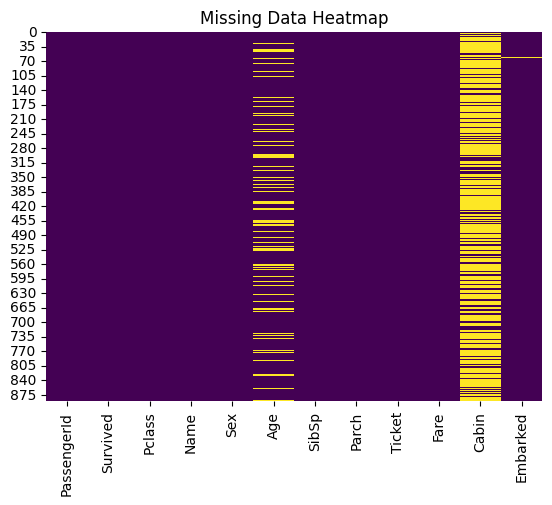

Missing Values Percentage:
 PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [11]:
# Visualize missing data
sns.heatmap(train.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

# Percentage of missing values
missing_percentage = (train.isnull().sum() / len(train)) * 100
print("Missing Values Percentage:\n", missing_percentage)

2. Checking for inconsistent data for test

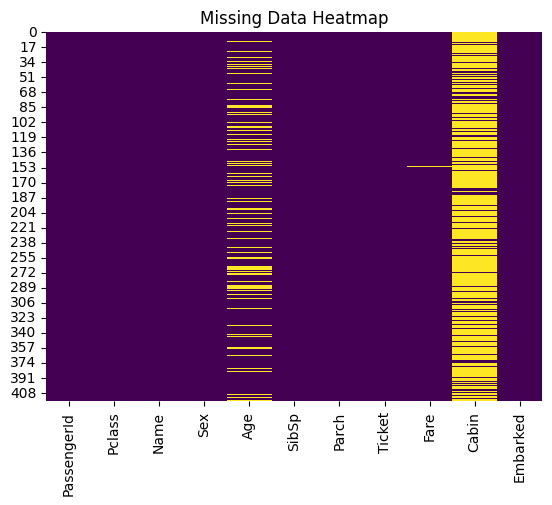

Missing Values Percentage:
 PassengerId     0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age             9.652076
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.112233
Cabin          36.700337
Embarked        0.000000
dtype: float64


In [12]:
# Visualize missing data
sns.heatmap(test.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

# Percentage of missing values
missing_percentage = (test.isnull().sum() / len(train)) * 100
print("Missing Values Percentage:\n", missing_percentage)

3. Checking for inconsistent data for random  

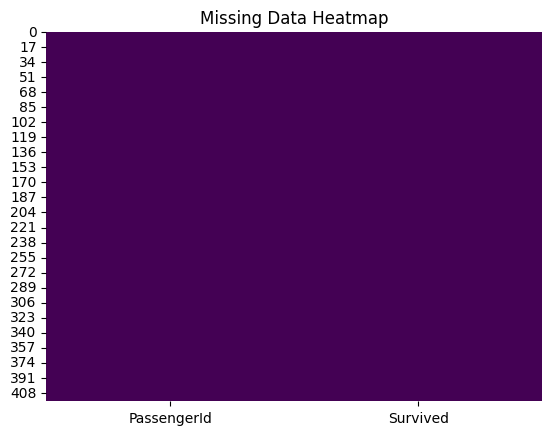

Missing Values Percentage:
 PassengerId    0.0
Survived       0.0
dtype: float64


In [13]:
# Visualize missing data
sns.heatmap(random.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

# Percentage of missing values
missing_percentage = (random.isnull().sum() / len(train)) * 100
print("Missing Values Percentage:\n", missing_percentage)

Results






* Every dataset is well structured and properly labelled.

*  There is no duplication of data.

* There is a significant amount of missing data in the training and testing data sets.

* The random dataset contains the test's passenger ID, as both have the same value (the same number from beginning to end and the same number of columns, and also with no duplication or inconsistency) as the test dataset and a survival column.



In conclusion, the random dataset is a subset of the train dataset, as it shares the same passenger ID while containing a survival feature that is missing in the test dataset.

This section also shows that there are a lot of missing values in the training dataset, making it necessary to fill them via feature engineering for more accurate EDA and to reduce bias in our ML model.

# Data preparation and Feature engineering
While the dataset is well-structured with clear labels and no duplication, there are missing values in the 'Embarked', 'Age', and 'Cabin' columns of the training dataset. To address this, we will perform data cleaning by filling in these missing values using appropriate imputation techniques and modifying certain values to make it simple for accurate EDA and to reduce data bias.

Filling missing values in Embarked using mode

In [14]:
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

<ipython-input-14-2c007674ec75>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)


 Filling missing value in age by using median of age colum

In [15]:
train['Age'] = train['Age'].fillna(train['Age'].median())

Generally, the cabin should be removed, as 50% of its data is missing. However, logically, it has a very high chance of predicting survival; as in a sinking ship, where you sit will be a very big factor in your survival. As such, the code will try its best to fill this column by modifying and filling missing values in Cabin by only using the cabin's first letter and removing other values and also filling missing values by comparing 'Pclass' and 'Fare' in relation to cabin values.

In [16]:
# Create a function to extract the first letter of the cabin
def get_cabin_first_letter(cabin):
    if pd.isnull(cabin):
        return 'M'  # Use 'M' for missing values initially
    else:
        return cabin[0]

# Apply the function to both train and test datasets
train['Cabin'] = train['Cabin'].apply(get_cabin_first_letter)



# Group data by Pclass and Fare, then fill missing Cabin values with the mode of each group
for pclass in train['Pclass'].unique():
    for fare in train['Fare'].unique():
        cabin_mode = train[(train['Pclass'] == pclass) & (train['Fare'] == fare)]['Cabin'].mode()
        if not cabin_mode.empty:
            train.loc[(train['Pclass'] == pclass) & (train['Fare'] == fare) & (train['Cabin'] == 'M'), 'Cabin'] = cabin_mode.iloc[0]

Checking changes in features of train datset

In [17]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S


Checking the result of changes in train data wile avoiding any changes in test data.

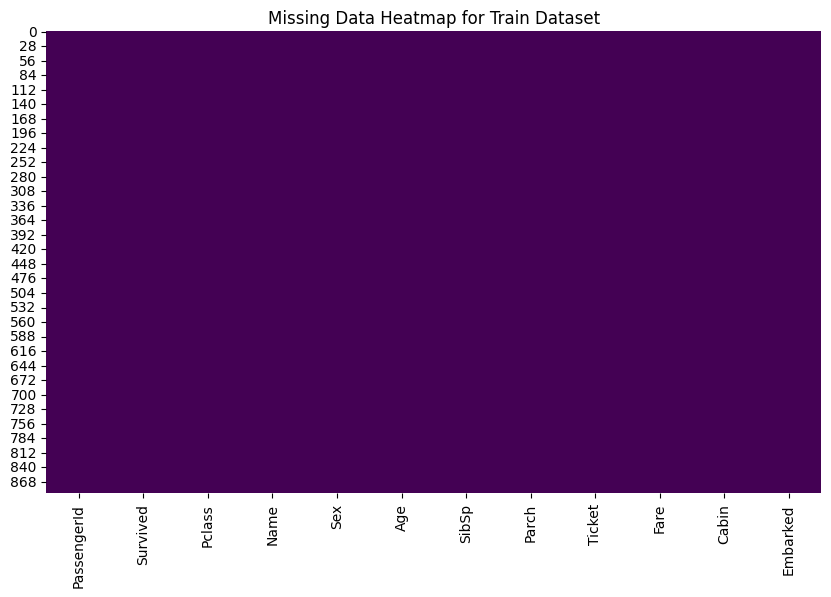

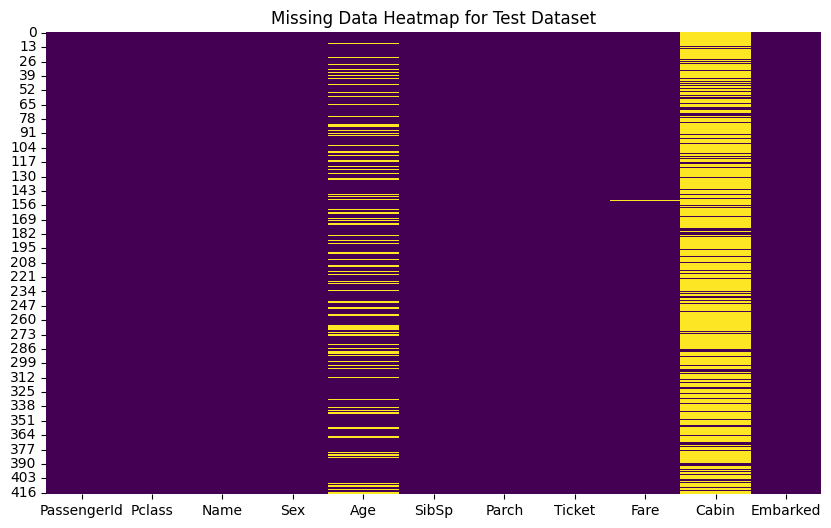

In [18]:
# Visualize missing data for train dataset
plt.figure(figsize=(10, 6))
sns.heatmap(train.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap for Train Dataset")
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(test.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap for Test Dataset")
plt.show()

**Conclusion**

We have now filled all the missing data from test dataset so now we can measure more accurate EDA and have more precises model that avoids any bias by avoiding duplicate or missing data.


# EDA
EDA, or exploratory data analysis, is a step where correlation between different features will be checked to know which features are needed and which ones are not, as the one with a big correlation has a higher chance to predict an accurate outcome than one with no correlation. In this section, for more efficient EDA, all the features have been compared to the survived feature for the goal of this project, which is to predict survival.



**1. Using plot to analysis survived rate with numeric values like 'PassengerId', 'Pclass', and 'Fare'**

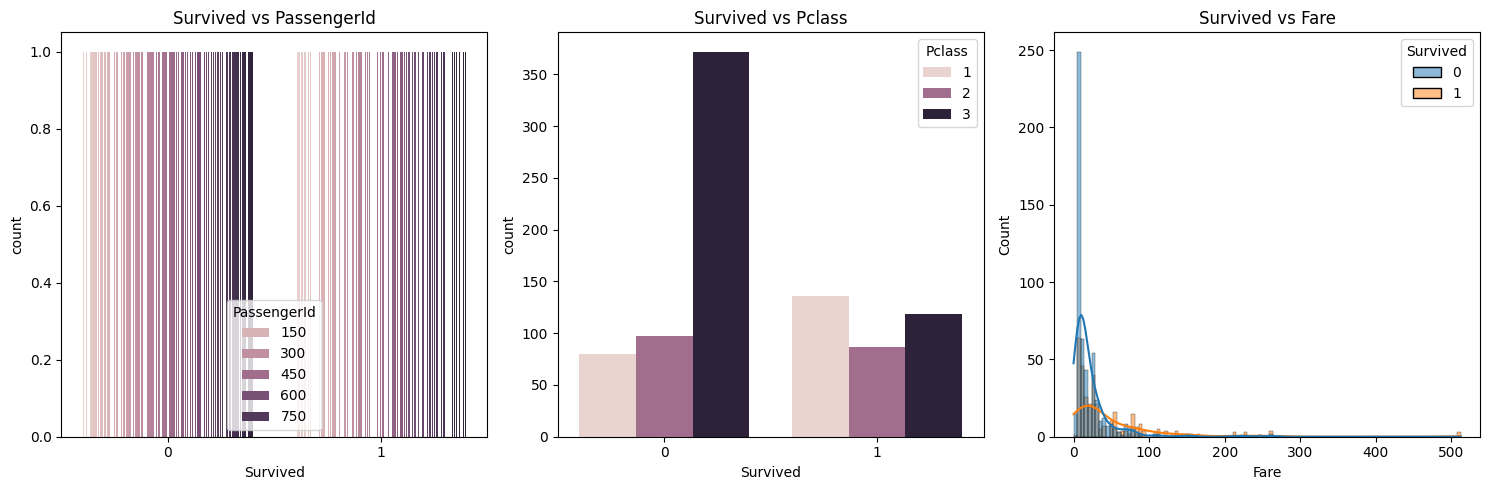

In [19]:
# Plotting 'Survived' vs. 'PassengerId', 'Pclass', and 'Fare'
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.countplot(x='Survived', hue='PassengerId', data=train)
plt.title('Survived vs PassengerId')

plt.subplot(1, 3, 2)
sns.countplot(x='Survived', hue='Pclass', data=train)
plt.title('Survived vs Pclass')

plt.subplot(1, 3, 3)
sns.histplot(x='Fare', hue='Survived', data=train, kde=True)  # Use histplot for numerical 'Fare'
plt.title('Survived vs Fare')

plt.tight_layout()
plt.show()

Results

1. passenger ID appears random, showing no meaningful correlation with survival outcomes.  

2. Survival varies by class:  
   - Higher survival rates in first class (1).  
   - Lower survival rates in third class (3), indicating a strong inverse correlation between class and survival.  

3.  Survivors generally paid higher fares compared to non-survivors. Fare has a positive correlation with survival likelihood.  

These insights highlight *Pclass* and *Fare* as important predictors, while *PassengerId* offers no predictive value.

**2. Using plot to analysis survived rate with passengers personal numeric data like 'Age’, 'number of Siblings', and 'Number of parents'**

<ipython-input-20-66cc0267777e>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Survived', y='Age', data=train, jitter=0.25, palette='Set2')
<ipython-input-20-66cc0267777e>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Survived', y='SibSp', data=train, jitter=0.25, palette='Set2')
<ipython-input-20-66cc0267777e>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Survived', y='Parch', data=train, jitter=0.25, palette='Set2')


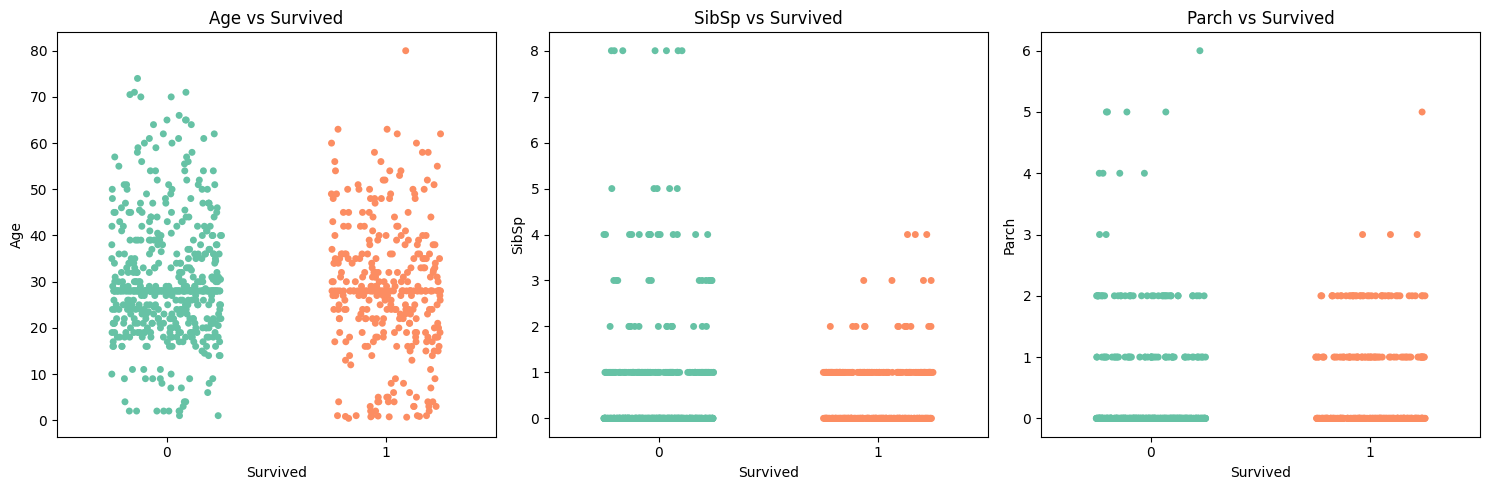

In [20]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.stripplot(x='Survived', y='Age', data=train, jitter=0.25, palette='Set2')
plt.title('Age vs Survived')

plt.subplot(1, 3, 2)
sns.stripplot(x='Survived', y='SibSp', data=train, jitter=0.25, palette='Set2')
plt.title('SibSp vs Survived')

plt.subplot(1, 3, 3)
sns.stripplot(x='Survived', y='Parch', data=train, jitter=0.25, palette='Set2')
plt.title('Parch vs Survived')

plt.tight_layout()
plt.show()


Result

* Mortality is high above 60 and low below 20 as such it’s a good indicator for survived in these age range. However, between 20 to 60 the ratio of life and death is similar and thus is not a reliable indicator.
* Death rate increases with the number of siblings and the increase is extreme form above the range of 4 siblings beyond that.  Thus, this is quiet good indicator.
* Same as siblings the survival decreased if you have more parents. After more than 3 parents death rate is high. As such it is also a good indicator.



3. Plot demonstrating direct and inverse corelation between each numeric element i.e.: ['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

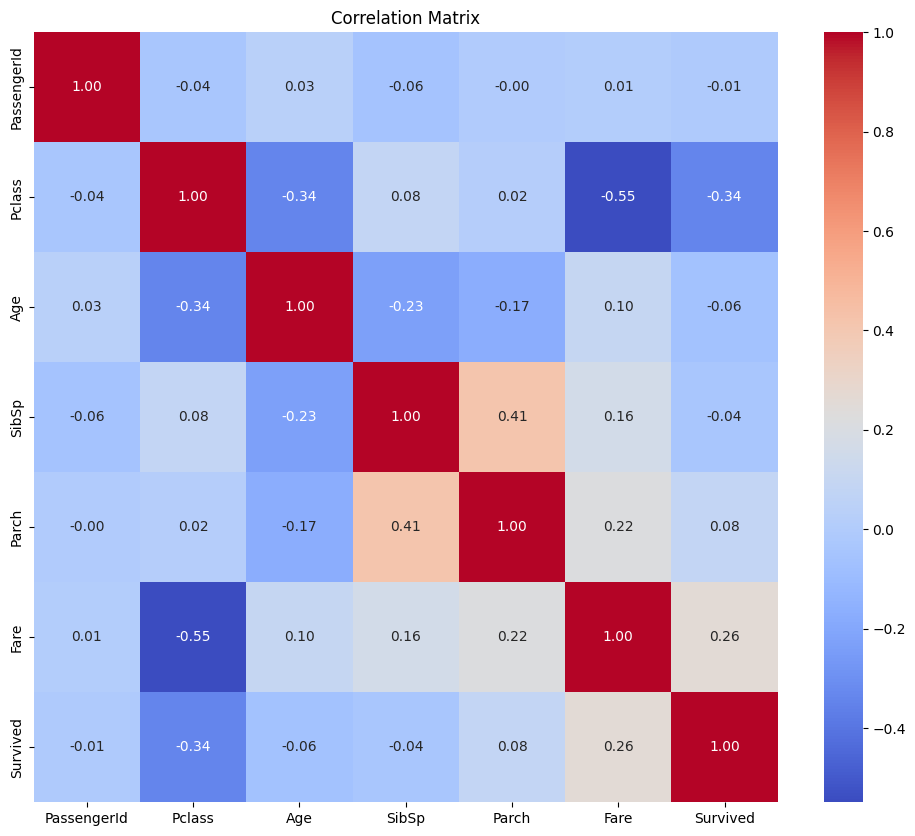

In [21]:
numeric_cols = ['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
plt.figure(figsize=(12, 10))
sns.heatmap(train[numeric_cols + ['Survived']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

Result:
* Fare and passenger class has good correlation to survivor and is good indicator of survived.
* Age, siblings and parents has some relation to survived but is not relabel metric to predict survived.
* Passenger id has almost no correlation with survival rate.
* passenger class has high corelation with fare and age.


4. Analysing survival rate to alphanumeric value

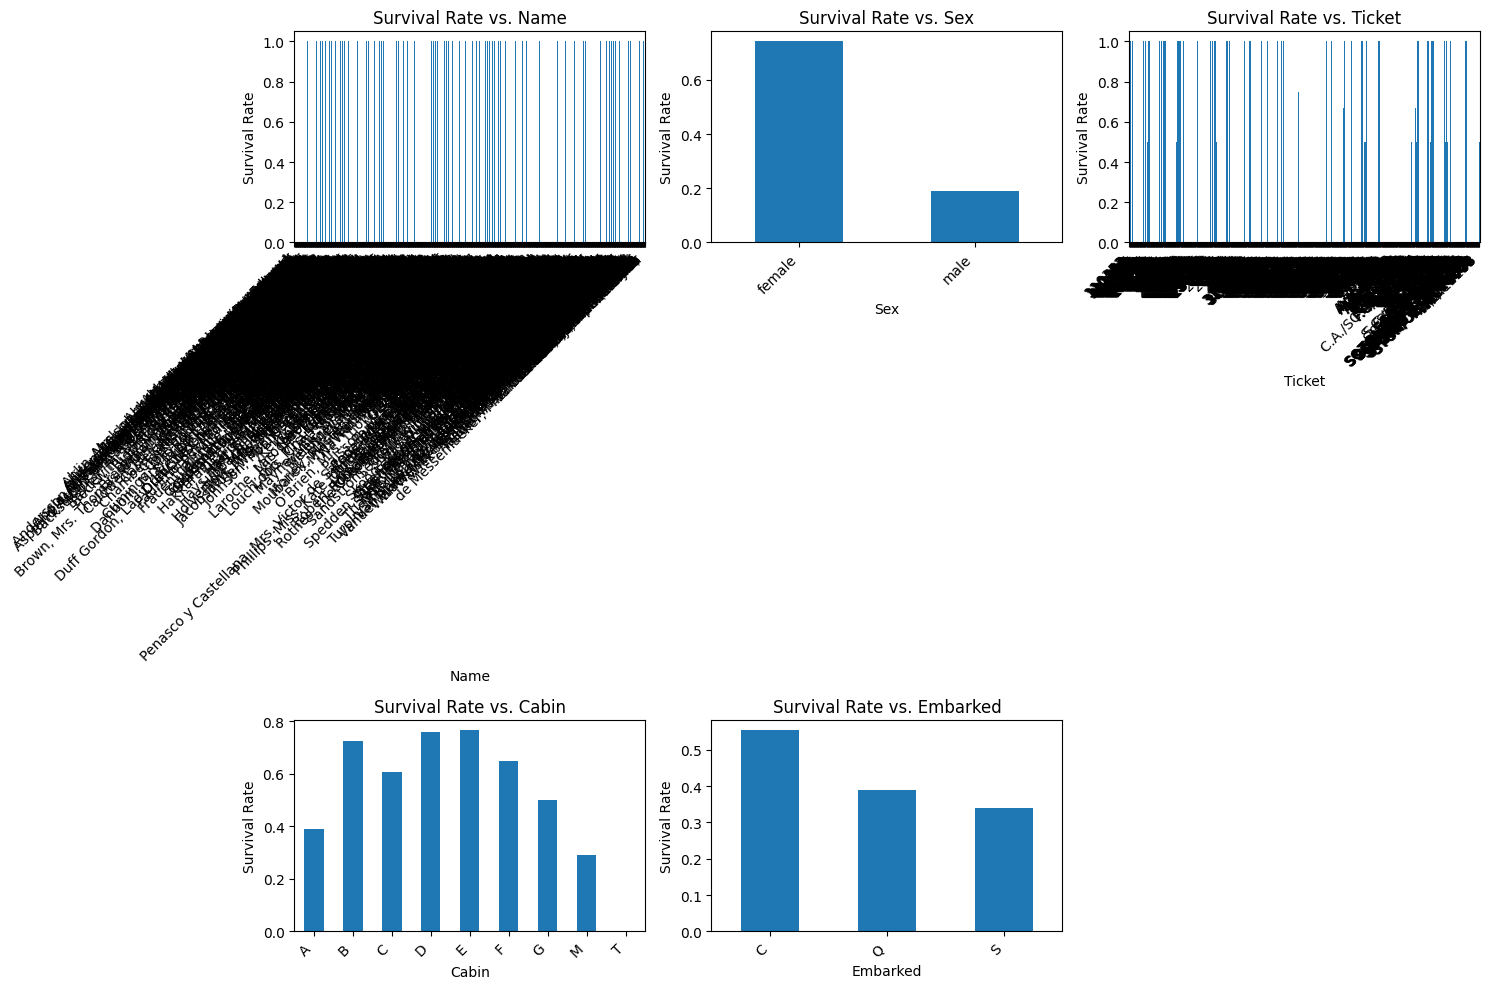

In [22]:
# Create the correlation plots for categorical features

categorical_cols = ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i + 1)

    # Calculate survival rate for each category
    survival_rates = train.groupby(col)['Survived'].mean()

    # Create the bar plot
    survival_rates.plot(kind='bar')
    plt.title(f'Survival Rate vs. {col}')
    plt.xlabel(col)
    plt.ylabel('Survival Rate')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Results:
* Name and ticket have very random rate of survivor and is bad indicator of prediction.
* Female have very high rate of survival compare to male. This makes it good indicator for prediction model.
* Cabin B, D and E have high level of survivor. C, F and G has decent rate of survivor. A and M has lower rate of survivor and finally T has extremely low chance of survivor. This makes it good indicator for prediction model.
* Embarked is also a good element for predicting survivor as C, Q and S  serially have highest to lower rate of survivor.


**EDA Conclusion**

AAccording to the charts, we have found out that there is almost no correlation between PassengerID, Name, and Ticket with survival rate as such; removing them in the machine learning stage will give higher accuracy.

# Decision Tree model


**Testing Decision Tree model**

Initially running the Decision Tree model by adding all the features of the training dataset. This is done to recognise the difference in accuracy before and after using feature selection and hyperparameter tuning on the model.
  

In [23]:
# Machine learning
train.head()

# Define features (X) and target variable (y)

features = ['PassengerId','Ticket' ,'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked']
X = train[features]
y = train['Survived']

# Convert categorical features to numerical using Label Encoding
label_encoders = {}
# Include 'Ticket' in the list of columns to be label encoded
for column in ['PassengerId','Sex', 'Name', 'Cabin', 'Embarked', 'Ticket']:
    label_encoders[column] = LabelEncoder()
    X[column] = label_encoders[column].fit_transform(X[column])


numerical_cols = ['Pclass','Age', 'SibSp', 'Fare', 'Parch']
for col in numerical_cols:
  X[col] = X[col].fillna(X[col].median())


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train a Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters as needed
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy}")

# Calculate and print the F1 score
f1 = f1_score(y_test, y_pred)
print(f"Decision Tree F1 Score: {f1}")

Decision Tree Accuracy: 0.7932960893854749
Decision Tree F1 Score: 0.7516778523489933


<ipython-input-23-607d24939ab1>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[column] = label_encoders[column].fit_transform(X[column])
<ipython-input-23-607d24939ab1>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[column] = label_encoders[column].fit_transform(X[column])
<ipython-input-23-607d24939ab1>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https

**Using Feature selection and Hyperparameter tuning**

After removing all unnecessary features according to the EDA and using hyperparameter tuning, we found out that accuracy decreased.

In [ ]:
# Initialize LabelEncoder
le = LabelEncoder()

# Handle missing values (if any) and encode categorical features
train_data = train.copy()

# Impute missing values for numerical columns only
numerical_cols = train_data.select_dtypes(include=np.number).columns
train_data[numerical_cols] = train_data[numerical_cols].fillna(train_data[numerical_cols].mean())

# According to charts and EDA CONCLUSION, we have found out that there is almost no correlation between
# Fare, Name, Ticket, and PassengerId with survival rate.  We will remove them.
# Define categorical and numerical features


numerical_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = [ 'Pclass', 'Sex', 'Cabin', 'Embarked']  #According to charts and EDA CONCLUSION,


# Create a ColumnTransformer to apply different preprocessing to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ])

# Apply preprocessing
X = preprocessor.fit_transform(train_data[numerical_features + categorical_features])
y = train_data['Survived']

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree classifier
clf = DecisionTreeClassifier(random_state=42)

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 8, 10],
    'max_features': ['sqrt', 'log2', None, 0.5, 0.7],
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random']
}

# GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)

# Get the best hyperparameters from the grid search
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

# Train the classifier with the best parameters
clf = DecisionTreeClassifier(random_state=42, **best_params)
clf.fit(x_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(x_test)

# Evaluate the model - A5+ccuracy and F1 Score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)  # Calculate F1 score

print(f"Accuracy: {accuracy}")
print(f"F1 Score: {f1}")  # Print F1 score

However, after adding passenger ID in those removed features, we have increased the accuracy. Unfortunately, this is the highest result possible, i.e., 81% accuracy and an even lower F1 score for the decision tree model.



In [ ]:
# Initialize LabelEncoder
le = LabelEncoder()

# Handle missing values (if any) and encode categorical features
train_data = train.copy()

# Impute missing values for numerical columns only
numerical_cols = train_data.select_dtypes(include=np.number).columns
train_data[numerical_cols] = train_data[numerical_cols].fillna(train_data[numerical_cols].mean())

# According to charts and EDA CONCLUSION, we have found out that there is almost no correlation between
# Fare, Name, Ticket, and PassengerId with survival rate.  We will remove them.
# Define categorical and numerical features


numerical_features = ['Age', 'SibSp', 'Parch', 'Fare']
#categorical_features = [ 'Pclass', 'Sex', 'Cabin', 'Embarked']  #According to charts and EDA CONCLUSION,
categorical_features = [ 'PassengerId','Pclass', 'Sex', 'Cabin', 'Embarked'] #including 'PassengerId' because it increased accuracy to highest possable rate

# Create a ColumnTransformer to apply different preprocessing to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ])

# Apply preprocessing
X = preprocessor.fit_transform(train_data[numerical_features + categorical_features])
y = train_data['Survived']

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree classifier
clf = DecisionTreeClassifier(random_state=42)

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 8, 10],
    'max_features': ['sqrt', 'log2', None, 0.5, 0.7],
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random']
}

# GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)

# Get the best hyperparameters from the grid search
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

# Train the classifier with the best parameters
clf = DecisionTreeClassifier(random_state=42, **best_params)
clf.fit(x_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(x_test)

# Evaluate the model - A5+ccuracy and F1 Score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)  # Calculate F1 score

print(f"Accuracy: {accuracy}")
print(f"F1 Score: {f1}")  # Print F1 score

**Testing the trained model**

Using the trained Decision Tree model, we will predict the survivor of test data and comparing the predicted data with survived column from random dataset. doing so, we will compare accuracy and f1 score with ROC Curve of test data.

In [ ]:
# Preprocess the test data using the same preprocessor used for training
test_data = test.copy()
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['PassengerId','Pclass', 'Sex', 'Cabin', 'Embarked']

# Instead of using 'numerical_cols', use 'numerical_features' which only contains
# columns present in both train and test datasets:
test_data[numerical_features] = test_data[numerical_features].fillna(test_data[numerical_features].mean())

# Apply the same preprocessing steps to the test dataset
X_test_processed = preprocessor.transform(test_data[numerical_features + categorical_features])


# Make predictions on the processed test data
test_predictions = clf.predict(X_test_processed)

# Create a DataFrame to store predictions
predictions_df = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived_Prediction': test_predictions})

# Merge the predictions with the 'random' dataset
merged_df = pd.merge(predictions_df, random, on='PassengerId', how='inner')

# Compare predictions and random survival values (Accuracy)
accuracy_comparison = accuracy_score(merged_df['Survived'], merged_df['Survived_Prediction'])

# Calculate F1 score
f1_comparison = f1_score(merged_df['Survived'], merged_df['Survived_Prediction'])

print(f"Accuracy comparison between the model's predictions and the random dataset: {accuracy_comparison}")
print(f"F1 Score comparison between the model's predictions and the random dataset: {f1_comparison}")

# Display the merged DataFrame with prediction and random survival values
print(merged_df.head())



# Get predicted probabilities for the test set (using the trained 'clf' model)
y_prob = clf.predict_proba(X_test_processed)[:, 1]  # Probability of class 1 (survival)

# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(merged_df['Survived'], y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Decision Tree')
plt.legend(loc="lower right")
plt.show()

# Random Forest Model


**Testing Random Forest Model**

Initially running Random Forest model by adding all the elements in train dataset. This is done so to recognise the difference in accuracy before and after feature selection process.

In [ ]:
# Define features (X) and target variable (y)
features = ['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
X = train[features].copy()  # Create a copy to avoid modifying the original DataFrame
y = train['Survived']

# Convert categorical features to numerical using Label Encoding
label_encoders = {}
for column in ['PassengerId', 'Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']:
    label_encoders[column] = LabelEncoder()
    X[column] = label_encoders[column].fit_transform(X[column])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train a Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)  # You can adjust hyperparameters
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Random Forest Accuracy: {accuracy}")
print(f"Random Forest F1 Score: {f1}")

Applying Feature selection according to EDA

In [ ]:
# Initialize LabelEncoder
le = LabelEncoder()

# Handle missing values (if any) and encode categorical features
train_data = train.copy()

# Impute missing values for numerical columns only
numerical_cols = train_data.select_dtypes(include=np.number).columns
train_data[numerical_cols] = train_data[numerical_cols].fillna(train_data[numerical_cols].mean())


# Define categorical and numerical features
categorical_features = [ 'Pclass', 'Sex', 'Cabin', 'Embarked']
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare']

# Create a ColumnTransformer to apply different preprocessing to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ])

# Apply preprocessing to the entire dataset (no train/test split for this task)
X = preprocessor.fit_transform(train_data[numerical_features + categorical_features])
y = train_data['Survived']

# Initialize and train the RandomForestClassifier on the entire dataset
rf_classifier = RandomForestClassifier(random_state=42)  # You can adjust hyperparameters here
rf_classifier.fit(X, y)

# Predict on the entire dataset (since we are calculating accuracy on all training elements)
y_pred = rf_classifier.predict(X)

# Evaluate accuracy
accuracy = accuracy_score(y, y_pred)
print(f"Random Forest Accuracy (on the entire training set): {accuracy}")

# Calculate and print the F1 score
f1 = f1_score(y, y_pred)
print(f"Random Forest F1 Score (on the entire training set): {f1}")

**Adding passenger ID**

Adding passenger ID in privious(random forest) model increased its accuracy of the model. Thus, checking if it is same of this model too.  

In [ ]:
# Initialize LabelEncoder
le = LabelEncoder()

# Handle missing values (if any) and encode categorical features
train_data = train.copy()

# Impute missing values for numerical columns only
numerical_cols = train_data.select_dtypes(include=np.number).columns
train_data[numerical_cols] = train_data[numerical_cols].fillna(train_data[numerical_cols].mean())


# Define categorical and numerical features
categorical_features = ['PassengerId', 'Pclass', 'Sex', 'Cabin', 'Embarked']
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare']

# Create a ColumnTransformer to apply different preprocessing to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ])

# Apply preprocessing to the entire dataset (no train/test split for this task)
X = preprocessor.fit_transform(train_data[numerical_features + categorical_features])
y = train_data['Survived']

# Initialize and train the RandomForestClassifier on the entire dataset
rf_classifier = RandomForestClassifier(random_state=42)  # You can adjust hyperparameters here
rf_classifier.fit(X, y)

# Predict on the entire dataset (since we are calculating accuracy on all training elements)
y_pred = rf_classifier.predict(X)

# Evaluate accuracy
accuracy = accuracy_score(y, y_pred)
print(f"Random Forest Accuracy (on the entire training set): {accuracy}")

# Calculate and print the F1 score
f1 = f1_score(y, y_pred)
print(f"Random Forest F1 Score (on the entire training set): {f1}")

Testing the trained model

Since the accuracy went upto 100% on train data we will be using the trained Random Forest model to predict the survivor of test data and comparing the predicted data with survived column from random dataset for accuracy and f1 score with ROC Curve.


In [ ]:
# Preprocess the test data using the same preprocessor used for training
test_data = test.copy()
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['PassengerId', 'Pclass', 'Sex', 'Cabin', 'Embarked']

# Instead of using 'numerical_cols', use 'numerical_features' which only contains
# columns present in both train and test datasets:
test_data[numerical_features] = test_data[numerical_features].fillna(test_data[numerical_features].mean())

# Apply the same preprocessing steps to the test dataset
X_test_processed = preprocessor.transform(test_data[numerical_features + categorical_features])

# Make predictions on the processed test data using the Random Forest model
test_predictions = rf_classifier.predict(X_test_processed)

# Create a DataFrame to store predictions
predictions_df = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived_Prediction': test_predictions})

# Merge the predictions with the 'random' dataset
merged_df = pd.merge(predictions_df, random, on='PassengerId', how='inner')

# Compare predictions and random survival values (Accuracy)
accuracy_comparison = accuracy_score(merged_df['Survived'], merged_df['Survived_Prediction'])

# Calculate F1 score
f1_comparison = f1_score(merged_df['Survived'], merged_df['Survived_Prediction'])

print(f"Accuracy comparison between the model's predictions and the random dataset: {accuracy_comparison}")
print(f"F1 Score comparison between the model's predictions and the random dataset: {f1_comparison}")

# Display the merged DataFrame with prediction and random survival values
print(merged_df.head())

# Get predicted probabilities for the test set (using the trained 'rf_classifier' model)
y_prob = rf_classifier.predict_proba(X_test_processed)[:, 1]  # Probability of class 1 (survival)

# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(merged_df['Survived'], y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Random Forest')
plt.legend(loc="lower right")
plt.show()


# Issue encountered During coding and hypothesis

1.	 Passenger ID has increased accuracy even if it was supposed to be impossible according to EDA. It might be because tree-based models may utilise hidden patterns in data, which might include sequential ordering, groupings, or hidden relationships to other features. Decision Trees might overfit to PassengerId due to its unique values, while Random Forest eliminates this by averaging predictions across numerous trees, enabling the feature to contribute without overwhelming the model.
2.	A decrease in the F1 score and an increase in accuracy in the final result of the decision tree. This may be due to hyperparameter tuning, where the model might favour the majority class to increase accuracy, creating an imbalance and decreasing the F1 score.
